In [1]:
# зависимости
import numpy as np
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import torchshow as ts
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [14]:
cifar_transform = transforms.Compose([
        transforms.ToTensor(),
    ])

In [15]:
cifar10_testset = torchvision.datasets.CIFAR10(root='cifar', train=False, download=True, transform=cifar_transform)

cifar10_train_set = torchvision.datasets.CIFAR10(root='cifar', train=True, download=True, transform=cifar_transform)
cifar10_train_set, cifar10_val_set = mnist_train, mnist_val = random_split(cifar10_train_set, [0.8, 0.2])
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

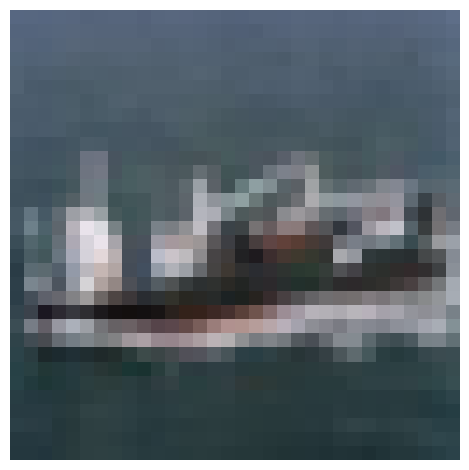

In [16]:
img, cls = cifar10_val_set[2]
ts.show(img)

In [17]:
img.shape

torch.Size([3, 32, 32])

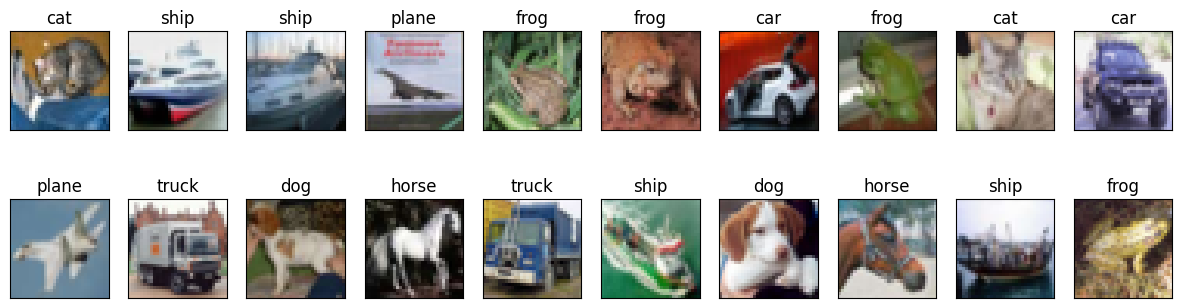

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(cifar10_testset[i][0].permute(1, 2, 0)
              )
    plt.xticks([])
    plt.yticks([])
    plt.title(classes[cifar10_testset[i][1]])

plt.show()

In [26]:
class SimpleVariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dim, img_shape=(3, 32, 32)):
        super().__init__()

        self.encoder_common = nn.Sequential(
            nn.Flatten(),
            nn.Linear(np.prod(img_shape), 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU()
        )
        self.encoder_m = nn.Linear(512, latent_dim)
        self.encoder_s = nn.Linear(512, latent_dim)

        self.N = torch.distributions.Normal(0, 1)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, np.prod(img_shape)),
            nn.Sigmoid(),
            nn.Unflatten(1, img_shape)
        )

    def encode(self, x):
        x = self.encoder_common(x)
        m = self.encoder_m(x)
        s = torch.exp(self.encoder_s(x))
        return m + s * self.N.sample(m.shape)

    def forward(self, x):
        x = self.encoder_common(x)
        m = self.encoder_m(x)
        s = torch.exp(self.encoder_s(x))
        z = m + s * self.N.sample(m.shape)
        y = self.decoder(z)
        return y, m, s

    def process(self, x):
        return self(x)[0]

In [29]:
from tqdm import tqdm

# одна эпоха обучения
def run_epoch(ae, opt, loss, dataloader, is_train=True):
    ae.train(is_train)
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for x, _ in tqdm(dataloader):
            x = x.to(device)
            reconstruction, mu, sigma = ae(x)
            recon_loss = loss(reconstruction, x)
            kl_loss = -0.5 * torch.sum(1 + torch.log(sigma**2) - mu**2 - sigma**2)
            l = recon_loss + kl_loss
            if (is_train):
                opt.zero_grad()
                l.backward()
                opt.step()
            total_loss += l.item()
    return total_loss / len(dataloader.dataset)

In [22]:
def plot_loss(loss, title, num_epochs):
    plt.title(title)
    plt.plot(loss)
    plt.grid()
    plt.xticks(np.arange(num_epochs))

def plot_losses(train, val, num_epochs):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 2, 1)
    plot_loss(train, f'Train Loss = {train[-1]}', num_epochs)
    plt.subplot(1, 2, 2)
    plot_loss(val, f'Val Loss = {val[-1]}', num_epochs)
    plt.show()

In [23]:
def show_examples(ae, dataset, size):
    ae.eval()
    with torch.no_grad():
        idxs = np.random.randint(0, len(dataset), size)
        x = torch.stack([dataset[i][0] for i in idxs]).to(device)
        y = ae.process(x)
        print("Original images")
        ts.show(x, nrows=1, figsize=(12, 2))
        print("Reconstructed")
        ts.show(y, nrows=1, figsize=(12, 2))

In [24]:
from IPython.display import clear_output

def run_train_loop(ae, opt, loss, train_loader, val_loader, num_epochs, ex_size):
    train_hist = []
    val_hist = []
    for e in range(num_epochs):
        print("Trainin...")
        train_loss = run_epoch(ae, opt, loss, train_loader)
        train_hist.append(train_loss)
        print("Validating...")
        val_loss = run_epoch(ae, opt, loss, val_loader, is_train=False)
        val_hist.append(val_loss)
        clear_output()
        plot_losses(train_hist, val_hist, num_epochs)
        show_examples(ae, val_loader.dataset, ex_size)

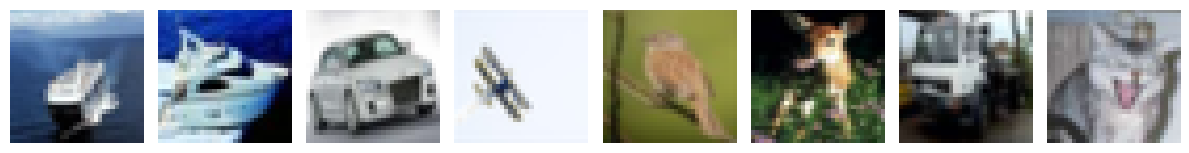

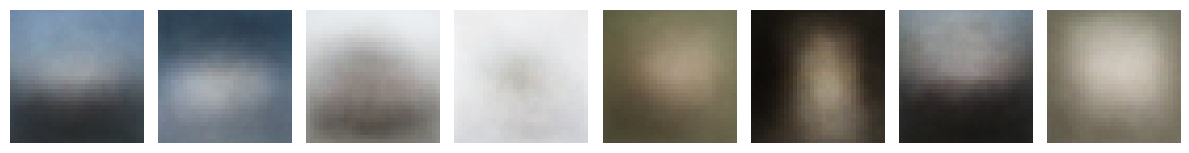

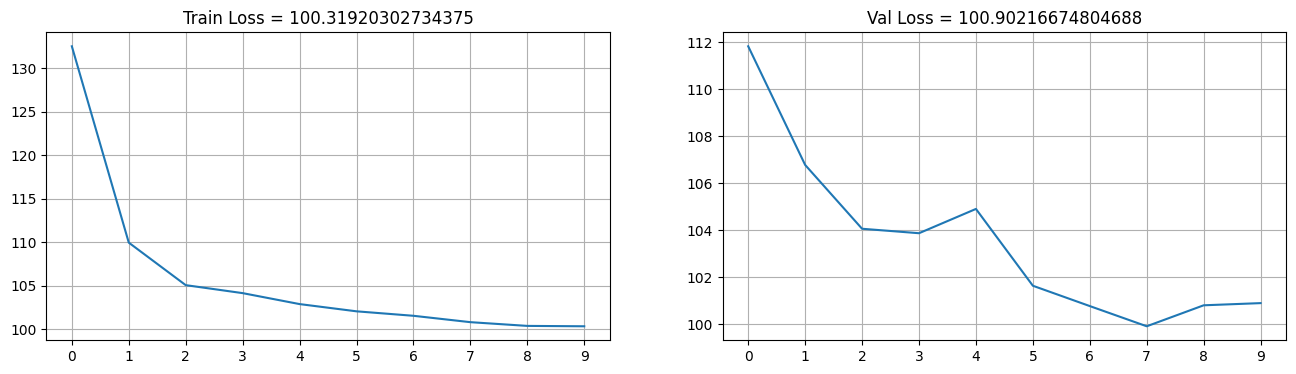

Original images
Reconstructed


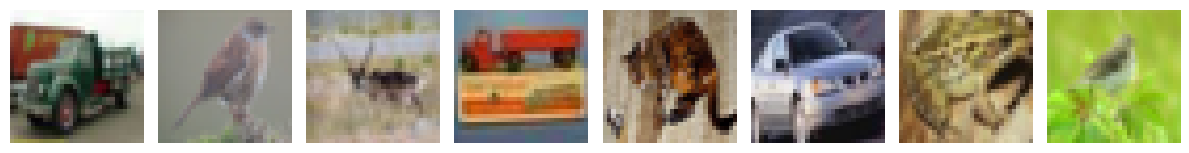

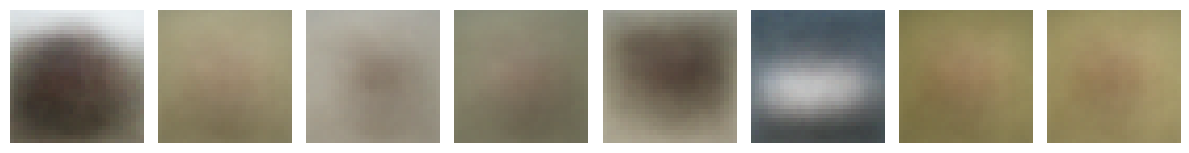

In [ ]:

batch_size = 256
num_epochs = 10
lat_dim = 4 # размерность скрытого пространства
ex_size = 8 # число примеров для отрисовки

train_loader = DataLoader(mnist_train, batch_size)
val_loader = DataLoader(mnist_val, batch_size)

sae = SimpleVariationalAutoEncoder(lat_dim).to(device)
sae_opt = optim.Adam(sae.parameters())
sae_loss = nn.MSELoss(reduction='sum')

run_train_loop(sae, sae_opt, sae_loss,
               train_loader, val_loader, num_epochs, ex_size)

In [ ]:
def show_enc_dist(ae, xi, yi, dataset, size):
    idxs = np.random.randint(0, len(dataset), size)
    ae.eval()
    with torch.no_grad():
        z = ae.encode(torch.stack([dataset[i][0] for i in idxs]).to(device))
    x = z[:,xi].cpu().numpy()
    y = z[:,yi].cpu().numpy()
    plt.figure(figsize=(8, 8))
    plt.scatter(x, y, c = [dataset[i][1] for i in idxs])
    plt.show()

In [ ]:
show_enc_dist(sae, 0, 1, mnist_val, 10000)